In [6]:
## IMPORTS
import numpy as np 
import matplotlib.pyplot as plt


## RK4
def kinematic_rk4(t, f, initconds, args=(), order=2):
    """
    Classical RK4 integrator for first- and second-order systems.

    Parameters
    ----------
    t : ndarray
        1D array of time points (uniform spacing assumed).

    f : callable

        If order == 2:
            f(t, r, v, *args) -> r''

        If order == 1:
            f(t, y, *args) -> y'

    initconds : list or tuple

        If order == 2:
            if 1D:
                [r(0),r'(0)]
            if ND:
                [[r_x(0),r_y(0),...],[r'_x(0),r'_y(0)],...]

        If order == 1:
            if 1D:
                [r(0)] or just r(0)
            if ndim
                [r_x(0),r_y(0),...] or [[r_x(0),r_y(0),...]]

    args : tuple or list, optional
        Extra parameters passed to f.

    order : int
        1 -> first-order system
        2 -> second-order system (default)

    Returns
    -------
    r : ndarray 
    v : ndarray
    a : ndarray

        order == 2:
            r = position
            v = velocity
            a = acceleration

        order == 1
            r  = position
            r' = vwlocity 
    """
    N = len(t)

    # ======================================================
    # SECOND ORDER SYSTEM
    # ======================================================
    if order == 2:
        
        r0, v0 = initconds

        r0 = np.atleast_1d(r0).astype(float)
        v0 = np.atleast_1d(v0).astype(float)

        dim = len(r0)

        r = np.zeros((N, dim))
        v = np.zeros((N, dim))
        a = np.zeros((N, dim))

        r[0] = r0
        v[0] = v0
        a[0] = f(t[0], r0, v0, *args)

        for i in range(N - 1):
            dt = t[i+1] - t[i]
            half_dt = dt / 2

            t_i = t[i]
            r_i = r[i]
            v_i = v[i]

            # k1
            k1_r = v_i
            k1_v = f(t_i, r_i, v_i, *args)

            # k2
            k2_r = v_i + half_dt * k1_v
            k2_v = f(t_i + half_dt,
                     r_i + half_dt * k1_r,
                     v_i + half_dt * k1_v,
                     *args)

            # k3
            k3_r = v_i + half_dt * k2_v
            k3_v = f(t_i + half_dt,
                     r_i + half_dt * k2_r,
                     v_i + half_dt * k2_v,
                     *args)

            # k4
            k4_r = v_i + dt * k3_v
            k4_v = f(t_i + dt,
                     r_i + dt * k3_r,
                     v_i + dt * k3_v,
                     *args)

            r[i+1] = r_i + dt * (k1_r + 2*k2_r + 2*k3_r + k4_r) / 6
            v[i+1] = v_i + dt * (k1_v + 2*k2_v + 2*k3_v + k4_v) / 6
            a[i+1] = f(t[i+1], r[i+1], v[i+1], *args)

        if dim == 1:
            return r[:,0], v[:,0], a[:,0]
        return r.T, v.T, a.T

    # ======================================================
    # FIRST ORDER SYSTEM
    # ======================================================
    elif order == 1:

        r0 = np.atleast_1d(initconds).astype(float)
        dim = len(r0)

        r = np.zeros((N, dim))
        v = np.zeros((N, dim))

        r[0] = r0
        v[0] = f(t[0], r0, *args)

        for i in range(N - 1):
            dt = t[i+1] - t[i]
            half_dt = dt / 2
            
            t_i = t[i]
            r_i = r[i]

            k1 = f(t_i, r_i, *args)
            k2 = f(t_i + half_dt, r_i + half_dt * k1, *args)
            k3 = f(t_i + half_dt, r_i + half_dt * k2, *args)
            k4 = f(t_i + dt, r_i + dt * k3, *args)

            r[i+1] = r_i + dt * (k1 + 2*k2 + 2*k3 + k4) / 6
            v[i+1] = f(t[i+1], r[i+1], *args)
            
        if dim == 1:
            return r[:,0], v[:,0]
        else:
            return r.T, v.T
    else:
        raise ValueError("order must be 1 or 2.")


def acc_g(t,r,v,mu):
    rmag = np.linalg.norm(r)
    if rmag == 0:
        return r * 0
    else:
        return - r * (mu / rmag**3)
    
## ELLIPSE POSITION
def conic(a, e, w =0, single = False,p=None , nu=0, resol=540, nu_min=0, nu_max=2*np.pi):
    theta = np.nan
    nu_inf = np.acos(-1/e) if e > 1 else None
    if single:
        if e > 1 and abs(nu) > nu_inf:
            print(f"BEYOND ORBIT ASYMPTOTE : {np.rad2deg(nu_inf)}")
            return [np.nan, np.nan]
        theta = nu
    else:
        if e > 1:
            nu_min = -nu_inf + 0.001
            nu_max = nu_inf - 0.001
        theta = np.linspace(nu_min, nu_max, resol)
    # Determine p (semi-latus rectum)
    if p is None:
        if e == 1:
            raise ValueError("For parabola (e=1), you must provide p explicitly (a is infinite)")
        p = a * (1 - e**2)
    r = p / (1 + e * np.cos(theta))
    r = r * np.array([np.cos(theta + w), 
                      np.sin(theta + w)
                    ])
    return r

## ELLIPSE VELOCITY
def obt_vel(mu,a, e, w = 0,single=False, p=None,nu=0, resol=540, nu_min=0, nu_max=2*np.pi):
    nu_inf = np.acos(-1/e) if e > 1 else None
    if single:
        if e > 1 and abs(nu) > nu_inf:
            print(f"BEYOND ORBIT ASYMPTOTE : {np.rad2deg(nu_inf)}")
            return [np.nan, np.nan]
        theta = nu
    else:
        if e > 1:
            nu_min = -nu_inf + 0.001
            nu_max = nu_inf - 0.001
        theta = np.linspace(nu_min, nu_max, resol)

    # Determine p (semi-latus rectum)
    if p is None:
        if a is None:
            raise ValueError("Either p or a must be provided")
        if e == 1:
            raise ValueError("For parabola (e=1), you must provide p explicitly (a is infinite)")
        p = a * (1 - e**2)
    # Velocity vector using simplified form
    v = np.sqrt(mu / p) * np.array([
        -np.sin(theta + w) - e * np.sin(w),
         np.cos(theta + w) + e * np.cos(w)
    ])
    
    return v

## UNIVERSAL VARIABLES FORMULATION LAMBERT SOLVER
def lambert_solver(r1, r2, tof, mu, t_m, N=0, max_iter=1000, tol=1e-6):
    """
    Universal Variables Lambert Solver
    
    Parameters:
    -----------
    r1, r2 : Initial and final position vectors
    tof    : Time of flight
    mu     : Gravitational parameter
    t_m    : Transfer type (1=prograde, -1=retrograde, 0=use N-rev)
    N      : Number of complete revolutions (only used if t_m=0)
    """
    
    def c_2(z):
        if z > 1e-12:
            return (1.0 - np.cos(np.sqrt(z))) / z
        elif z < -1e-12:
            return (1.0 - np.cosh(np.sqrt(-z))) / z
        else:
            # Taylor series for stability near zero
            return 0.5 - z/24.0 + z*z/720.0 - z*z*z/40320.0
    
    def c_3(z):
        if z > 1e-12:
            sqrt_z = np.sqrt(z)
            return (sqrt_z - np.sin(sqrt_z)) / (sqrt_z * z)
        elif z < -1e-12:
            sqrt_neg = np.sqrt(-z)
            return (np.sinh(sqrt_neg) - sqrt_neg) / (sqrt_neg * (-z))
        else:
            # Taylor series for stability near zero
            return 1.0/6.0 - z/120.0 + z*z/5040.0 - z*z*z/362880.0

    mag_r1 = np.linalg.norm(r1)
    mag_r2 = np.linalg.norm(r2)
    gamma = np.dot(r1, r2) / (mag_r1 * mag_r2)
    
    # Cross product for transfer angle determination
    cross_r1r2 = np.cross(r1, r2)
    
    # Determine A based on transfer type
    if t_m == 1:  # Prograde (0 < theta < pi)
        A = np.sqrt(mag_r1 * mag_r2 * (1 + gamma))
    elif t_m == -1:  # Retrograde (pi < theta < 2pi)
        A = -np.sqrt(mag_r1 * mag_r2 * (1 + gamma))
    else:  # N-revolution case
        A = np.sqrt(mag_r1 * mag_r2 * (1 + gamma))
        if cross_r1r2[2] < 0:  # Adjust sign based on z-component
            A = -A

    if A == 0:
        print("Error: A = 0 (orbit cannot exist)")
        return [np.array([np.inf, np.inf]), np.array([np.inf, np.inf])]

    # Set initial bounds based on revolution case
    if N == 0:
        psi_l = -4.0 * np.pi**2 
        psi_u = 4.0 * np.pi**2
        psi = 0.0  # Initial guess
    else:
        # For N-revolution case
        psi_l = (2.0 * N * np.pi)**2
        psi_u = (2.0 * (N + 1) * np.pi)**2
        psi = (psi_l + psi_u) / 2.0
    
    solved = False
    
    for i in range(max_iter):
        c2 = c_2(psi)
        c3 = c_3(psi)
        
        # Compute B
        B = mag_r1 + mag_r2 + A * (psi * c3 - 1.0) / np.sqrt(c2)
        
        # Ensure B is valid (should be positive for physical solution)
        if B < 0:
            psi_l = psi
            psi = (psi_u + psi_l) / 2.0
            continue
        
        # Compute time of flight for this psi
        chi = np.sqrt(B / c2)
        chi3 = chi**3
        tof_ = (chi3 * c3 + A * np.sqrt(B)) / np.sqrt(mu)
        
        # Check convergence
        if np.abs(tof_ - tof) < tol:
            solved = True
            break
        
        # Update bounds using bisection
        if tof_ < tof:
            psi_l = psi
        else:
            psi_u = psi
        
        psi = (psi_u + psi_l) / 2.0
    
    if not solved:
        print(f"Warning: Did not converge after {max_iter} iterations")
        print(f"  Final psi: {psi}, tof error: {abs(tof_ - tof)}")
        return [np.array([np.inf, np.inf]), np.array([np.inf, np.inf])]
    
    # Compute final velocities
    f = 1.0 - B / mag_r1
    g = A * np.sqrt(B / mu)
    g_dot = 1.0 - B / mag_r2
    
    # Avoid division by zero
    if abs(g) < 1e-12:
        print("Error: g is near zero (singularity)")
        return [np.array([np.inf, np.inf]), np.array([np.inf, np.inf])]
    
    f_dot = (f * g_dot - 1.0) / g
    
    v1 = (r2 - f * r1) / g
    v2 = f_dot * r1 + g_dot * v1
    
    return [v1, v2]

## TIME FROM NOW - 1 ORBIT OF TGT BODY
## ARRIVAL TIME - 1 ORBIT OF TGT BODY
mu = 4*np.pi**2

In [7]:
r1 = np.array([1,0,0])
r2 = np.array([0,2,0])
mu = 1
tof = 10
v1, v2 = lambert_solver(r1, r2, tof, mu,+1)
print(v1,v2)

[0.8751542  0.78794378 0.        ] [-0.39397189 -0.48118231  0.        ]


[[-0.98480775 -1.15845593]
 [ 0.17364818 -0.81115958]]
[[ 0.         -0.98480775]
 [ 0.          0.17364818]]
T1 = 6.283185307179586	T2 = 1.896699977380996


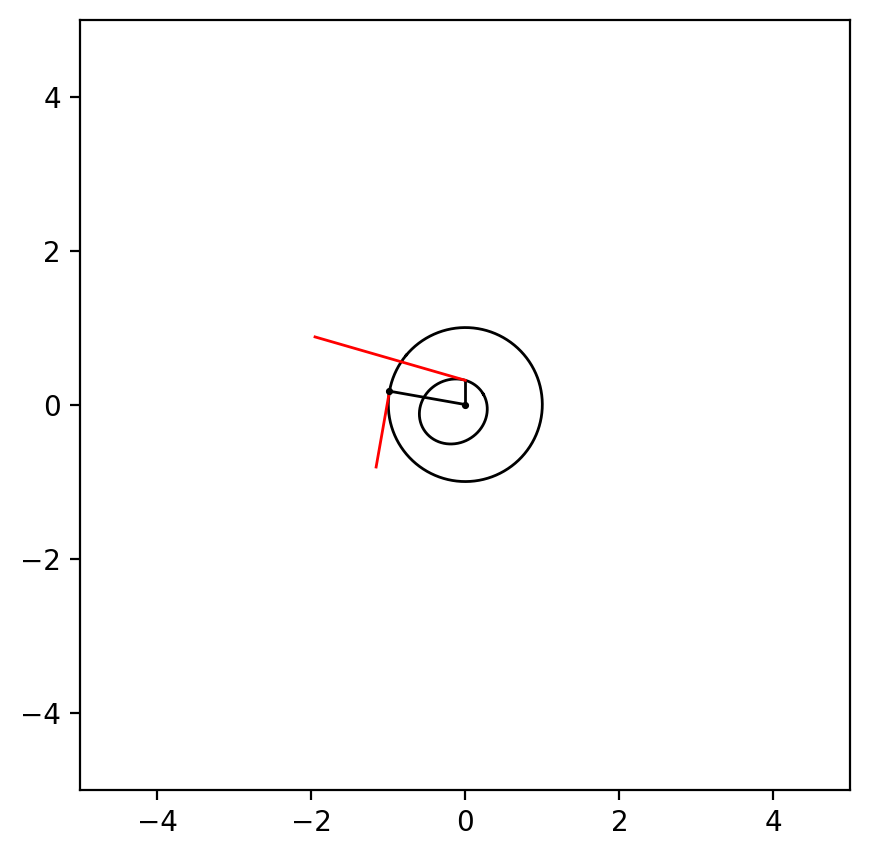

In [20]:
nu1 = np.deg2rad(30)
nu2 = np.deg2rad(60)
p0 = np.array([0.0,0.0])

a1 = 1
e1 = 0
w1 = np.deg2rad(140)

obt1 = conic(a1,e1,w1)
r1 = conic(a1,e1,w1,single=True,nu=nu1)
v1 = obt_vel(mu,a1,e1,w1,single=True,nu=nu1)
r1v = np.vstack([p0,r1]).T
v1v = np.vstack([r1,r1+v1]).T

a2 = 0.45
e2 = 0.4
w2 = np.deg2rad(30)

obt2 = conic(a2,e2,w2)
r2 = conic(a2,e2,w2,single=True,nu=nu2)
v2 = obt_vel(mu,a2,e2,w2,single=True,nu=nu2)
r2v = np.vstack([p0,r2]).T
v2v = np.vstack([r2,r2+v2]).T

T1 = 2*np.pi*np.sqrt(a1**3 / mu)
T2 = 2*np.pi*np.sqrt(a2**3 / mu)

print(v1v)
print(r1v)
print(f"T1 = {T1}\tT2 = {T2}")
plt.figure(figsize = (5,5),dpi = 200)

plt.plot(obt1[0],obt1[1],'k-',lw=1)
plt.plot(r1v[0],r1v[1],'k-',lw=1)
plt.plot(v1v[0],v1v[1],'r-',lw=1)

plt.plot(obt2[0],obt2[1],'k-',lw=1)
plt.plot(r2v[0],r2v[1],'k-',lw=1)
plt.plot(v2v[0],v2v[1],'r-',lw=1)
sq = 5
plt.scatter(0,0,color='k',s=2.5)
plt.scatter(r1[0],r1[1],color='k',s=2.5,zorder =5)
plt.xlim(-sq,sq)
plt.ylim(-sq,sq)
plt.gca().set_aspect("equal")
plt.show()

In [9]:
# nu = np.deg2rad(30)

# a = 1
# e = 0.4
# w = np.deg2rad(140)

# # initial state
# r0 = conic(a, e, w, single=True, nu=nu)
# v0 = obt_vel(mu, a, e, w, single=True, nu=nu)
# obt = conic(a,e,w)
# t = np.arange(0, 10, 0.1)
# dt = t[1] - t[0]

# # storage
# obt1 = np.zeros((len(t), 2))
# obt2 = np.zeros((len(t), 2))

# obt1[0] = r0
# obt2[0] = r0

# # separate state vectors
# r1 = r0.copy()
# v1 = v0.copy()

# r2 = r0.copy()
# v2 = v0.copy()

# for i in range(len(t)-1):

#     # -------------------------
#     # method 1: v then r (semi-implicit Euler)
#     # -------------------------
#     a1 = acc_g(t[i], r1, v1, mu)
#     v1 = v1 + a1 * dt
#     r1 = r1 + v1 * dt
#     obt1[i+1] = r1

#     # -------------------------
#     # method 2: r then v (explicit Euler)
#     # -------------------------
#     a2 = acc_g(t[i], r2, v2, mu)
#     r2 = r2 + v2 * dt
#     v2 = v2 + a2 * dt
#     obt2[i+1] = r2
    
# plt.plot(obt[0],obt[1],'k-',lw=1)
# plt.plot(obt1.T[0],obt1.T[1],'r-',lw=1)
# plt.plot(obt2.T[0],obt2.T[1],'b-',lw=1)
# plt.gca().set_aspect("equal")

T1 = 6.283185307179586	T2 = 1.896699977380996	 Tref = 6.283185307179586
t max = 6.28


C:\Users\verci\AppData\Local\Temp\ipykernel_18036\3923243617.py:260: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  cross_r1r2 = np.cross(r1, r2)


T1 = 6.283185307179586	T2 = 1.896699977380996	 Tref = 1.896699977380996
0.22 1.7166370614359177
11 23
0.2772247463669191
0.22 2.176637061435918
11 46
0.2772247463669191
0.22 2.6366370614359185
11 69
0.2158873285331891
0.22 3.096637061435919
11 92
0.2158873285331891
0.22 3.5566370614359193
11 115
0.2158873285331891
0.22 4.01663706143592
11 138
0.2158873285331891
0.22 4.47663706143592
11 161
0.38107504749359544
0.44 1.7166370614359177
22 23
0.2772247463669191
0.44 2.176637061435918
22 46
0.2158873285331891
0.44 2.6366370614359185
22 69
0.2158873285331891
0.44 3.096637061435919
22 92
0.2158873285331891
0.44 3.5566370614359193
22 115
0.2158873285331891
0.44 4.01663706143592
22 138
0.38107504749359544
0.44 4.47663706143592
22 161
0.38107504749359544
0.66 1.7166370614359177
33 23
0.2772247463669191
0.66 2.176637061435918
33 46
0.2158873285331891
0.66 2.6366370614359185
33 69
0.2158873285331891
0.66 3.096637061435919
33 92
0.2158873285331891
0.66 3.5566370614359193
33 115
0.2158873285331891
0

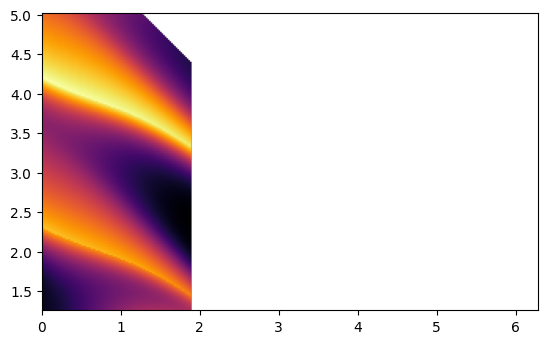

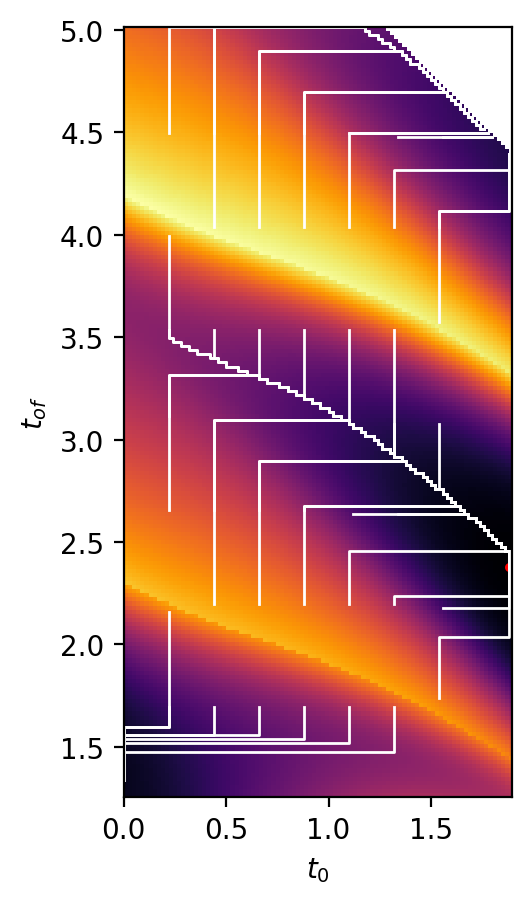

(np.float64(1.8800000000000001), np.float64(2.3766370614359182))
a transfer = 0.7224182304492144
T1 = 6.283185307179586	T2 = 1.896699977380996	 Tp = 3.8580061344251906
Minimum dV = 0.215887
94 213
1.8800000000000001 4.26 2.3766370614359182


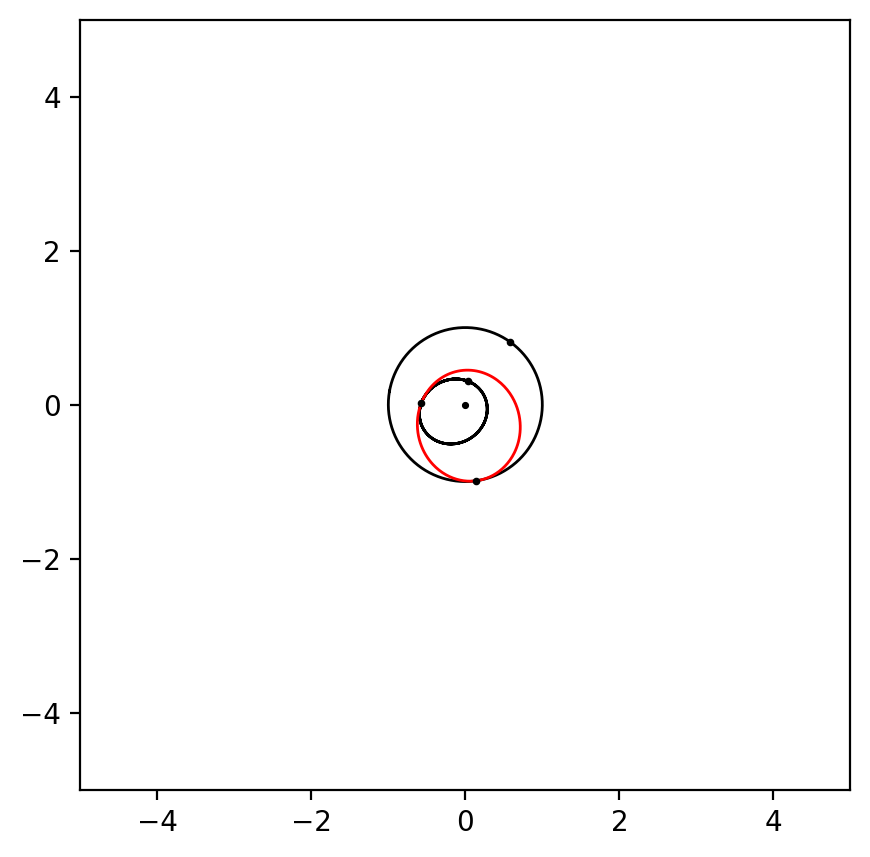

0.22 1.7166370614359177
11 23
0.5248905943541637
0.22 2.176637061435918
11 46
0.5248905943541637
0.22 2.6366370614359185
11 69
0.8243051824700444
0.22 3.096637061435919
11 92
0.8243051824700444
0.22 3.5566370614359193
11 115
0.8323296329940104
0.22 4.01663706143592
11 138
0.8323296329940104
0.22 4.47663706143592
11 161
0.8123626811291034
0.44 1.7166370614359177
22 23
0.5248905943541637
0.44 2.176637061435918
22 46
0.5324269740884868
0.44 2.6366370614359185
22 69
0.5324269740884868
0.44 3.096637061435919
22 92
0.5324269740884868
0.44 3.5566370614359193
22 115
0.8027543735687914
0.44 4.01663706143592
22 138
0.8123626811291034
0.44 4.47663706143592
22 161
0.8123626811291034
0.66 1.7166370614359177
33 23
0.5248905943541637
0.66 2.176637061435918
33 46
0.5324269740884868
0.66 2.6366370614359185
33 69
0.5324269740884868
0.66 3.096637061435919
33 92
0.5324269740884868
0.66 3.5566370614359193
33 115
0.5324269740884868
0.66 4.01663706143592
33 138
0.8123626811291034
0.66 4.47663706143592
33 161

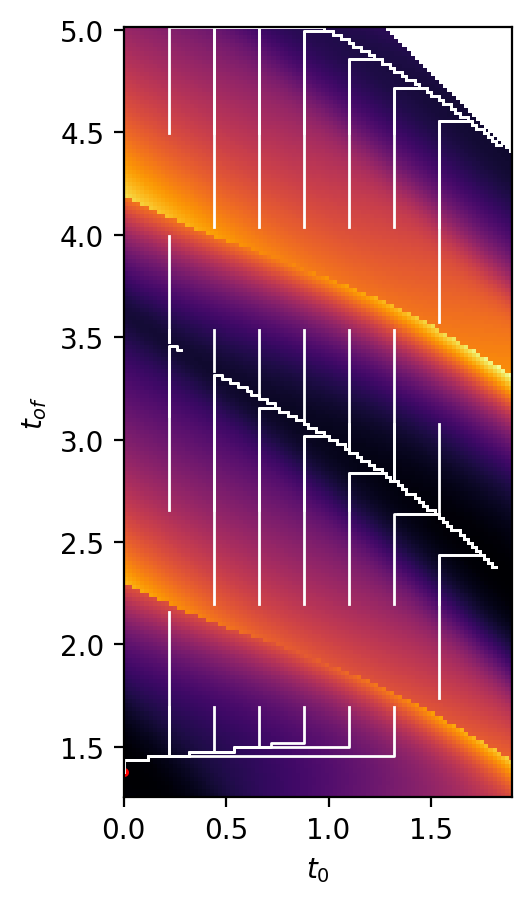

a transfer = 0.6814338327967875
T1 = 6.283185307179586	T2 = 1.896699977380996	 Tp = 3.53439762515428
Minimum dV = 0.278096
0 69
0.0 1.3800000000000001 1.3766370614359174


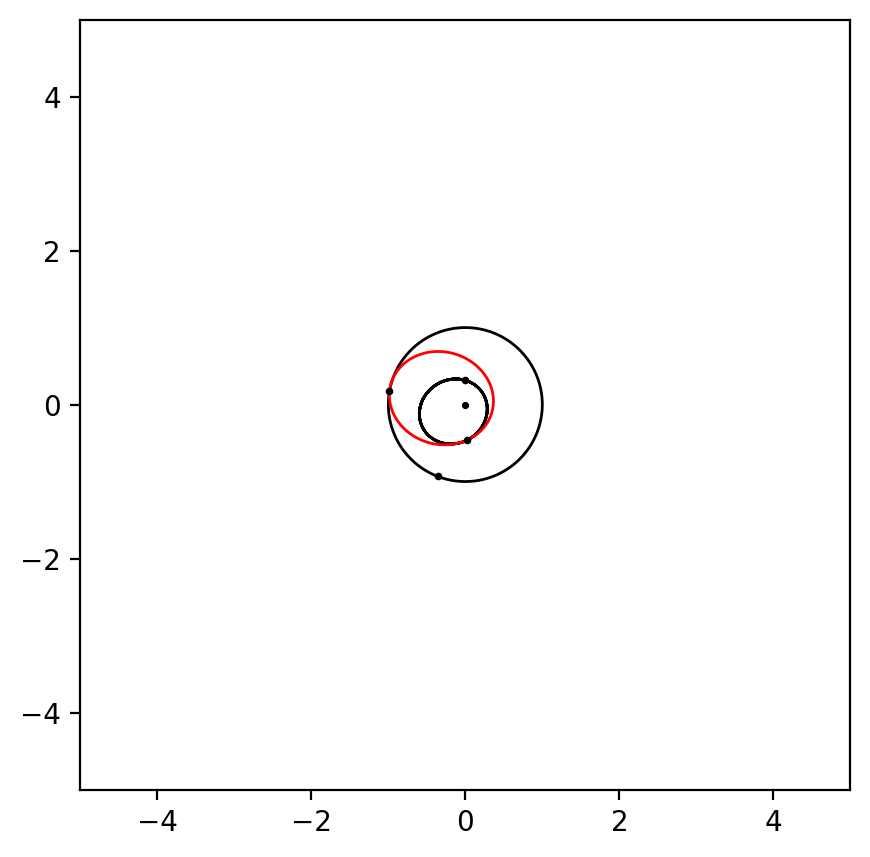

In [21]:
dt = 0.02
if T1 > T2:
    Tref = T1
else:
    Tref = T2
print(f"T1 = {T1}\tT2 = {T2}\t Tref = {Tref}")


t = np.arange(0,Tref,dt)
tof = np.arange(0.2*Tref,0.8*Tref,dt)
# resol = 200
# t = np.linspace(0,Tref,resol)
# tof = np.linspace(0.1*Tref,0.6*Tref,resol)


ro1, vo1, ao1 = kinematic_rk4(t,acc_g,[r1,v1],[mu]) # just an rk4 propagation.
ro2, vo2, ao2 = kinematic_rk4(t,acc_g,[r2,v2],[mu])

if T1 < T2:
    Tref = T1
else:
    Tref = T2

## PORKCHOP PLOT
vector_array = np.zeros((len(t),len(tof),2))
deltaV_array = np.zeros((len(t),len(tof)))
deltaV_2array = np.zeros((len(t),len(tof)))
t_max = t[-1]
print(f"t max = {t_max}")
for i,t_i in enumerate(t):
    for j,tof_i in enumerate(tof):
        t_arrival = t_i + tof_i
        if t_i > Tref: #Tref:
            vector_array[i,j]  = [np.inf, np.inf]
            deltaV_array[i,j]  = np.inf
            deltaV_2array[i,j] = np.inf
            continue
        if t_arrival > t_max:
            vector_array[i,j]  = [np.inf, np.inf]
            deltaV_array[i,j]  = np.inf
            deltaV_2array[i,j] = np.inf
        else:
            idx0 = np.argmin(np.abs(t-t_i))
            idx1 = np.argmin(np.abs(t-t_arrival))
            vt1, vt2 = lambert_solver(ro1.T[idx0],ro2.T[idx1],tof_i,mu,+1)
            if np.dot(vo1.T[idx0],vt1) < 0:
                vt1, vt2 = lambert_solver(ro1.T[idx0],ro2.T[idx1],tof_i,mu,-1)
            vector_array[i,j]  = vt1
            deltaV_array[i,j]  = np.linalg.norm(vt1 - vo1.T[idx0])
            deltaV_2array[i,j] = np.linalg.norm(vt1 - vo1.T[idx0]) + np.linalg.norm(vt2 - vo2.T[idx1])

plt.imshow(deltaV_array.T,extent=[t.min(),t.max(),tof.min(),tof.max()],cmap="inferno",origin='lower')

print(f"T1 = {T1}\tT2 = {T2}\t Tref = {Tref}")
deltaV_array = deltaV_array[t<=Tref]
deltaV_2array = deltaV_2array[t<=Tref]

plt.figure(figsize=(5,5),dpi=200)
N = 8
lx = len(deltaV_array) // N
ly = len(deltaV_array[0]) // N
init_pts = []
for i in range(1,N):
    for j in range(1,N):
        init_pts.append([i * lx, j*ly])

for pt in init_pts:
    idxi, idxy = pt
    minima_found = False
    print(t[idxi],tof[idxy])
    print(idxi,idxy) 
    current_pt = (idxi,idxy)
    lowest_pt  = (idxi,idxy)
    pathgraph = []
    while not minima_found:
        idxi, idxy = current_pt

        best_val = deltaV_array[idxi, idxy]
        lowest_pt = current_pt

        neighbors = [
            (idxi, idxy + 1),
            (idxi, idxy - 1),
            (idxi + 1, idxy),
            (idxi - 1, idxy)
            # ,(idxi + 1, idxy + 1),
            # (idxi - 1, idxy + 1),
            # (idxi + 1, idxy - 1),
            # (idxi - 1, idxy - 1),
        ]

        for n in neighbors:
            nx, ny = n
            if nx < 0 or ny < 0 or nx >= deltaV_array.shape[0] or ny >= deltaV_array.shape[1]:
                continue

            dVn = deltaV_array[nx, ny]
            # print(f"{nx} {ny} {best_val} {dVn}")
            if dVn < best_val:
                best_val = dVn
                lowest_pt = (nx, ny)

        if current_pt == lowest_pt:
            # print(current_pt)
            minima_found = True
            print(best_val)
        else:
            current_pt = lowest_pt

        pathgraph.append(current_pt)
    pathgraph =(np.array(pathgraph).T)
    pathgraph_x = np.vstack([
        t[pathgraph[0]],
        tof[pathgraph[1]]
    ])
    plt.plot(pathgraph_x[0],pathgraph_x[1],'w-',lw=1)



plt.imshow(deltaV_array.T,extent=[t.min(),Tref,tof.min(),tof.max()],cmap="inferno",origin='lower')
# plt.plot(pathgraph_x[0],pathgraph_x[1],'w-',lw=1)
plt.xlabel("$t_0$")
plt.ylabel("$t_{of}$")

## DEMONSTRATION THAT IT WORKS 1 WAY
min_val = np.min(deltaV_array)
rows, cols = np.where(deltaV_array == min_val)
idx0 = rows[0]  
idx1 = cols[0]  
print(idx0,idx1)
v01 = vector_array[idx0,idx1]
t0 = t[idx0]
tof_ = tof[idx1]
plt.scatter(t0,tof_,color='r',s=5)
plt.show()

print((t0, tof_))
idx0 = np.argmin(np.abs(t-t0))
idx1 = np.argmin(np.abs(t-(t0+tof_)))
r01 = ro1.T[idx0]
a_transfer = 1/(2/np.linalg.norm(r01) - np.linalg.norm(v01)**2 / mu)
Tp = 2 * np.pi * np.sqrt( a_transfer**3 / mu)
print(f"a transfer = {a_transfer}")
print(f"T1 = {T1}\tT2 = {T2}\t Tp = {Tp}")
# tofran = np.arange(0,tof_,dt)
tofran = np.arange(0,Tp,dt)
print(f"Minimum dV = {np.linalg.norm(v01 - vo1.T[idx0]):2f}")
print(idx0,idx1)
print(t0,t[idx1],tof_)
rt1, vt1, at1 = kinematic_rk4(tofran,acc_g,[ro1.T[idx0],v01],[mu])
plt.figure(figsize = (5,5),dpi = 200)
plt.plot(ro1[0],ro1[1],'k-',lw=1)
plt.plot(ro2[0],ro2[1],'k-',lw=1)
plt.plot(rt1[0],rt1[1],'r-',lw=1)
plt.scatter(0,0,color='k',s=2.5)
plt.scatter(ro1[0][idx0],ro1[1][idx0],color='k',s=3,zorder =5)
plt.scatter(ro2[0][idx0],ro2[1][idx0],color='k',s=3,zorder =5)
plt.scatter(ro1[0][idx1],ro1[1][idx1],color='k',s=3,zorder =5)
plt.scatter(ro2[0][idx1],ro2[1][idx1],color='k',s=3,zorder =5)
plt.xlim(-sq,sq)
plt.ylim(-sq,sq)
plt.gca().set_aspect("equal")
plt.show()

plt.figure(figsize=(5,5),dpi=200)
N = 8
lx = len(deltaV_2array) // N
ly = len(deltaV_2array[0]) // N
init_pts = []
for i in range(1,N):
    for j in range(1,N):
        init_pts.append([i * lx, j*ly])

for pt in init_pts:
    idxi, idxy = pt
    minima_found = False
    print(t[idxi],tof[idxy])
    print(idxi,idxy) 
    current_pt = (idxi,idxy)
    lowest_pt  = (idxi,idxy)
    pathgraph = []
    while not minima_found:
        idxi, idxy = current_pt

        best_val = deltaV_2array[idxi, idxy]
        lowest_pt = current_pt

        neighbors = [
            (idxi, idxy + 1),
            (idxi, idxy - 1),
            (idxi + 1, idxy),
            (idxi - 1, idxy)
            # ,(idxi + 1, idxy + 1),
            # (idxi - 1, idxy + 1),
            # (idxi + 1, idxy - 1),
            # (idxi - 1, idxy - 1),
        ]

        for n in neighbors:
            nx, ny = n
            if nx < 0 or ny < 0 or nx >= deltaV_2array.shape[0] or ny >= deltaV_2array.shape[1]:
                continue

            dVn = deltaV_2array[nx, ny]
            # print(f"{nx} {ny} {best_val} {dVn}")
            if dVn < best_val:
                best_val = dVn
                lowest_pt = (nx, ny)

        if current_pt == lowest_pt:
            # print(current_pt)
            minima_found = True
            print(best_val)
        else:
            current_pt = lowest_pt

        pathgraph.append(current_pt)
    pathgraph =(np.array(pathgraph).T)
    pathgraph_x = np.vstack([
        t[pathgraph[0]],
        tof[pathgraph[1]]
    ])
    plt.plot(pathgraph_x[0],pathgraph_x[1],'w-',lw=1)

plt.imshow(deltaV_2array.T,extent=[t.min(),Tref,tof.min(),tof.max()],cmap="inferno",origin='lower')
plt.xlabel("$t_0$")
plt.ylabel("$t_{of}$")

## DEMONSTRATION THAT IT WORKS 2 WAY
min_val = np.min(deltaV_2array)
rows, cols = np.where(deltaV_2array == min_val)
idx0 = rows[0]  
idx1 = cols[0]  
v01 = vector_array[idx0,idx1]
t0 = t[idx0]
tof_ = tof[idx1]
plt.scatter(t0,tof_,color='r',s=5)
plt.show()
idx0 = np.argmin(np.abs(t-t0))
idx1 = np.argmin(np.abs(t-(t0+tof_)))
r01 = ro1.T[idx0]
a_transfer = 1/(2/np.linalg.norm(r01) - np.linalg.norm(v01)**2 / mu)
Tp = 2 * np.pi * np.sqrt( a_transfer**3 / mu)
print(f"a transfer = {a_transfer}")
print(f"T1 = {T1}\tT2 = {T2}\t Tp = {Tp}")
# tofran = np.arange(0,tof_,dt)
tofran = np.arange(0,Tp,dt)
print(f"Minimum dV = {np.linalg.norm(v01 - vo1.T[idx0]):2f}")
print(idx0,idx1)
print(t0,t[idx1],tof_)
rt1, vt1, at1 = kinematic_rk4(tofran,acc_g,[ro1.T[idx0],v01],[mu])
plt.figure(figsize = (5,5),dpi = 200)
plt.plot(ro1[0],ro1[1],'k-',lw=1)
plt.plot(ro2[0],ro2[1],'k-',lw=1)
plt.plot(rt1[0],rt1[1],'r-',lw=1)
plt.scatter(0,0,color='k',s=2.5)
plt.scatter(ro1[0][idx0],ro1[1][idx0],color='k',s=3,zorder =5)
plt.scatter(ro2[0][idx0],ro2[1][idx0],color='k',s=3,zorder =5)
plt.scatter(ro1[0][idx1],ro1[1][idx1],color='k',s=3,zorder =5)
plt.scatter(ro2[0][idx1],ro2[1][idx1],color='k',s=3,zorder =5)
plt.xlim(-sq,sq)
plt.ylim(-sq,sq)
plt.gca().set_aspect("equal")
plt.show()



In [11]:
tmin = t[idx0]
tmax = t[idx0] + tofran[-1]
t = t[(t>=tmin) & (t<=tmax)] 
print(f"tmin = {t.min()}\ttmax = {t.max()}")

tmin = 2.22	tmax = 6.28


40
4.790000000000386 0.0008950748392602258


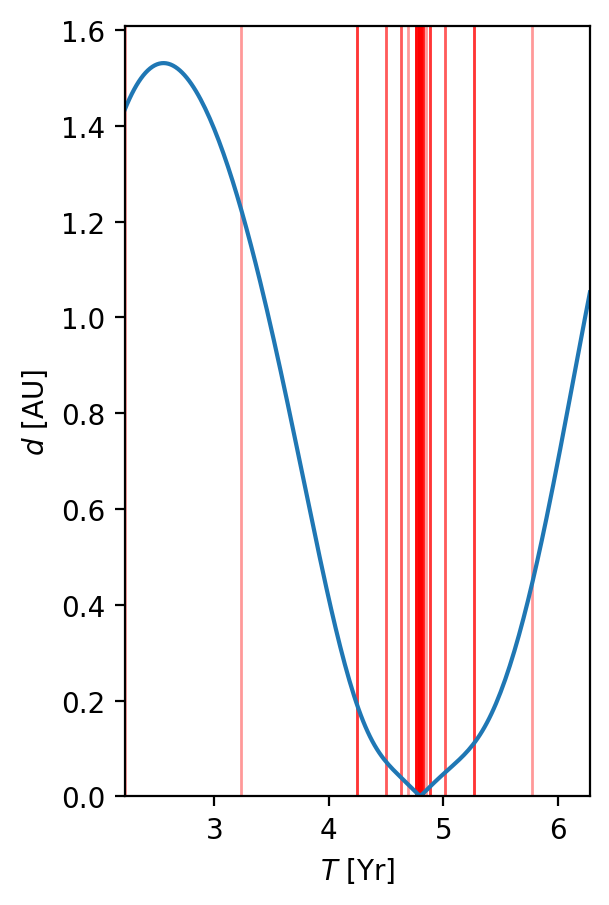

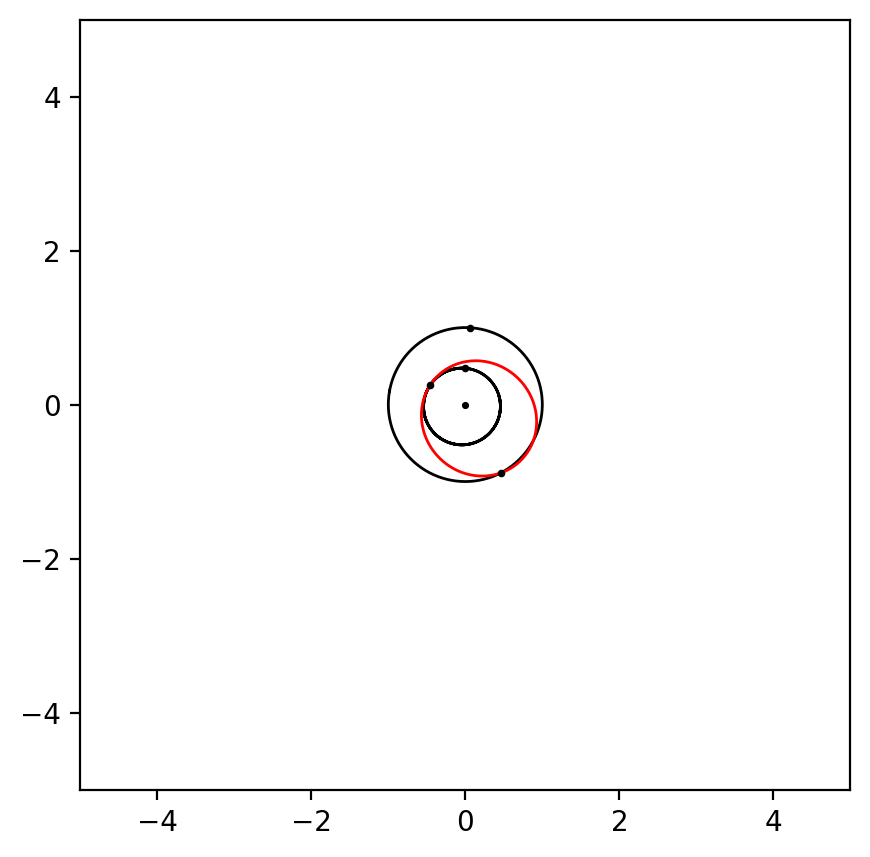

In [12]:

def distance_func(t_x):
    t_idx = np.argmin(np.abs(t-t_x))
    t_fdx = np.argmin(np.abs(tofran + t[0] - t_x))
    dist = ro2.T[t_idx + idx0] - rt1.T[t_fdx]
    return np.linalg.norm(dist)

plt.figure(figsize=(3,5),dpi=200)
def minima_finder(t0,tf,distance_func, max_iter = 100, tol = 1e-12):
    tlist = np.zeros(5)
    for i in range(5):
        tlist[i] = t0 + (i/4) * (tf-t0)

    def find_minidx(tlist):
        min_idx = 0
        for i in range(5):
            if distance_func(tlist[i]) < distance_func(tlist[min_idx]):
                min_idx = i 
        return min_idx
    
    min_t = np.inf 
    for i in range(max_iter):
        for j in range(5):
            plt.axvline(tlist[j],color='r',ls='-',lw=1,alpha = 0.4)
        minidx = find_minidx(tlist)
        if minidx == 0:
            l0 = tlist[0]
            l2 = tlist[1]
            l4 = tlist[2]
        elif minidx == 4:
            l0 = tlist[2]
            l2 = tlist[3]
            l4 = tlist[4]
        else:
            l0 = tlist[minidx-1]
            l2 = tlist[minidx]
            l4 = tlist[minidx+1]
        if i == max_iter - 1:
            min_t = l2 
        l1 = (l0+l2)/2
        l3 = (l2+l4)/2      
        if (np.abs(l0-l2)<tol) and (np.abs(l2-l4)<tol) :
            min_t = l2 
            max_i = i
            break
        else:
            tlist = [l0,l1,l2,l3,l4]
    print(max_i)
    if np.abs(min_t - t0)<tol or np.abs(min_t-tf) < tol:
        print(f"[ CAUTION ] Global minima outside given range {t0} to {tf}")
    return min_t

t_min = minima_finder(t.min(),t.max(),distance_func)
print(t_min, distance_func(t_min))
plt.plot(t,[distance_func(t_x) for t_x in t]) 
plt.xlim(t.min(),t.max())
plt.ylim(0,None)
plt.xlabel("$T$ [Yr]")
plt.ylabel("$d$ [AU]")
plt.show()

idxc = np.argmin(np.abs(t-t_min))
plt.figure(figsize = (5,5),dpi = 200)
plt.plot(ro1[0],ro1[1],'k-',lw=1)
plt.plot(ro2[0],ro2[1],'k-',lw=1)
plt.plot(rt1[0],rt1[1],'r-',lw=1)
plt.scatter(0,0,color='k',s=2.5)
plt.scatter(ro1[0][idx0],ro1[1][idx0],color='k',s=3,zorder =5)
plt.scatter(ro2[0][idx0],ro2[1][idx0],color='k',s=3,zorder =5)
plt.scatter(ro1[0][idx1],ro1[1][idx1],color='k',s=3,zorder =5)
plt.scatter(ro2[0][idx1],ro2[1][idx1],color='k',s=3,zorder =5)
# plt.scatter(ro1[0][idxc],ro1[1][idxc],color='k',s=3,zorder =5)
# plt.scatter(ro2[0][idxc],ro2[1][idxc],color='k',s=3,zorder =5)
plt.xlim(-sq,sq)
plt.ylim(-sq,sq)
plt.gca().set_aspect("equal")
plt.show() 

60
4.809999999999841 0.0008950748392602258


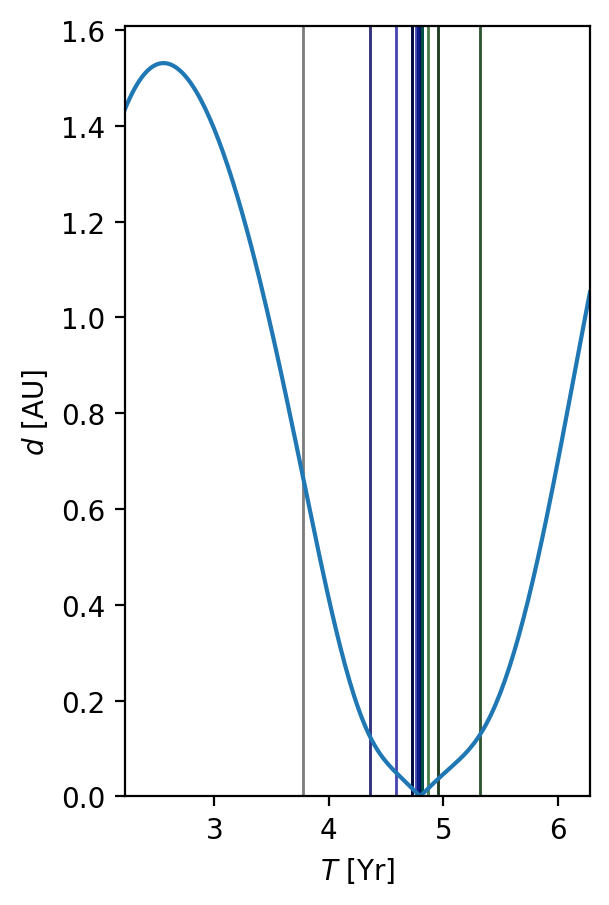

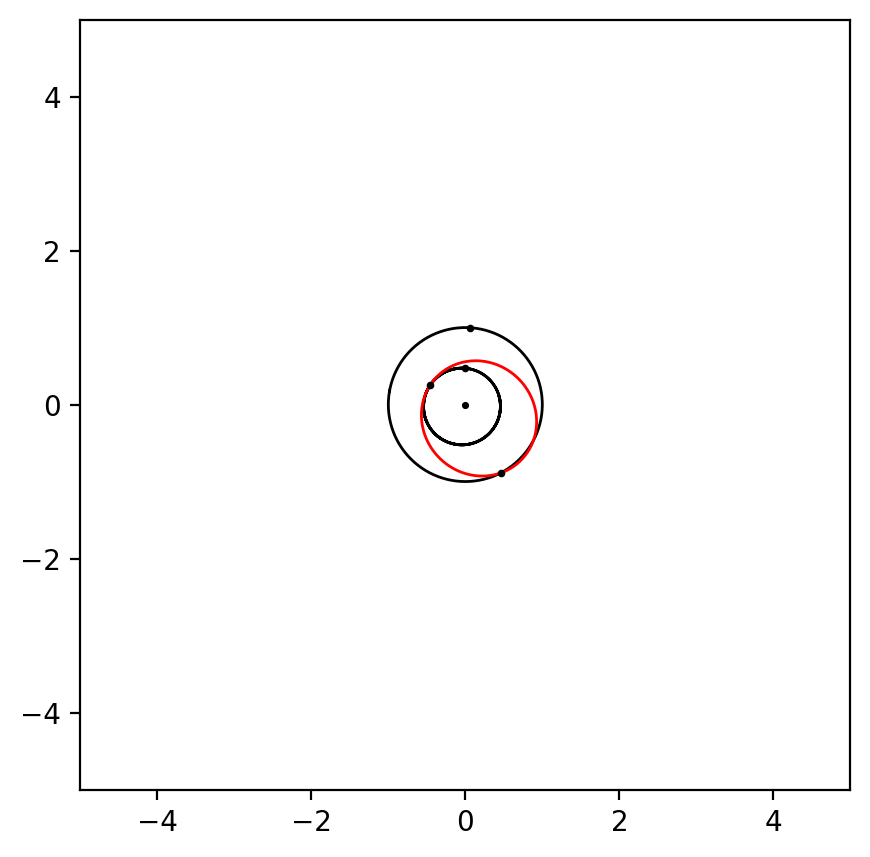

In [13]:

def distance_func(t_x):
    t_idx = np.argmin(np.abs(t-t_x))
    t_fdx = np.argmin(np.abs(tofran + t[0] - t_x))
    dist = ro2.T[t_idx + idx0] - rt1.T[t_fdx]
    return np.linalg.norm(dist)
plt.figure(figsize=(3,5),dpi=200)

def minima_finder(t0, tf, f, max_iter=100, tol=1e-12):
    phi = (1 + 5**0.5) / 2
    resphi = 2 - phi

    ta, tb = t0, tf
    t1 = ta + resphi * (tb - ta)
    t2 = tb - resphi * (tb - ta)
    f1, f2 = f(t1), f(t2)

    max_i = max_iter

    for i in range(max_iter):
        if f1 < f2:
            tb = t2
            t2 = t1
            f2 = f1
            t1 = ta + resphi * (tb - ta)
            f1 = f(t1)
        else:
            ta = t1
            t1 = t2
            f1 = f2
            t2 = tb - resphi * (tb - ta)
            f2 = f(t2)

        if abs(tb - ta) < tol:
            max_i = i
            break

        # plotting
        plt.axvline(ta, color='black', lw=1, alpha=0.3)
        plt.axvline(tb, color='black', lw=1, alpha=0.3)
        plt.axvline(t1, color='blue', lw=1, alpha=0.6)
        plt.axvline(t2, color='green', lw=1, alpha=0.6)

    t_min = (ta + tb) / 2
    f_min = f(t_min)

    f_left = f(t0)
    f_right = f(tf)

    if (f_left < f_min) or (f_right < f_min):
        print(f"[ CAUTION ] Minimum may lie at or outside bounds [{t0}, {tf}]")

    print(max_i)
    return t_min

t_min = minima_finder(t.min(),t.max(),distance_func)
print(t_min, distance_func(t_min))
plt.plot(t,[distance_func(t_x) for t_x in t]) 
plt.xlim(t.min(),t.max())
plt.ylim(0,None)
plt.xlabel("$T$ [Yr]")
plt.ylabel("$d$ [AU]")
plt.show()

idxc = np.argmin(np.abs(t-t_min))
plt.figure(figsize = (5,5),dpi = 200)
plt.plot(ro1[0],ro1[1],'k-',lw=1)
plt.plot(ro2[0],ro2[1],'k-',lw=1)
plt.plot(rt1[0],rt1[1],'r-',lw=1)
plt.scatter(0,0,color='k',s=2.5)
plt.scatter(ro1[0][idx0],ro1[1][idx0],color='k',s=3,zorder =5)
plt.scatter(ro2[0][idx0],ro2[1][idx0],color='k',s=3,zorder =5)
plt.scatter(ro1[0][idx1],ro1[1][idx1],color='k',s=3,zorder =5)
plt.scatter(ro2[0][idx1],ro2[1][idx1],color='k',s=3,zorder =5)
# plt.scatter(ro1[0][idxc],ro1[1][idxc],color='k',s=3,zorder =5)
# plt.scatter(ro2[0][idxc],ro2[1][idxc],color='k',s=3,zorder =5)
plt.xlim(-sq,sq)
plt.ylim(-sq,sq)
plt.gca().set_aspect("equal")
plt.show() 

17
4.790000000000244 0.0008950748392602258


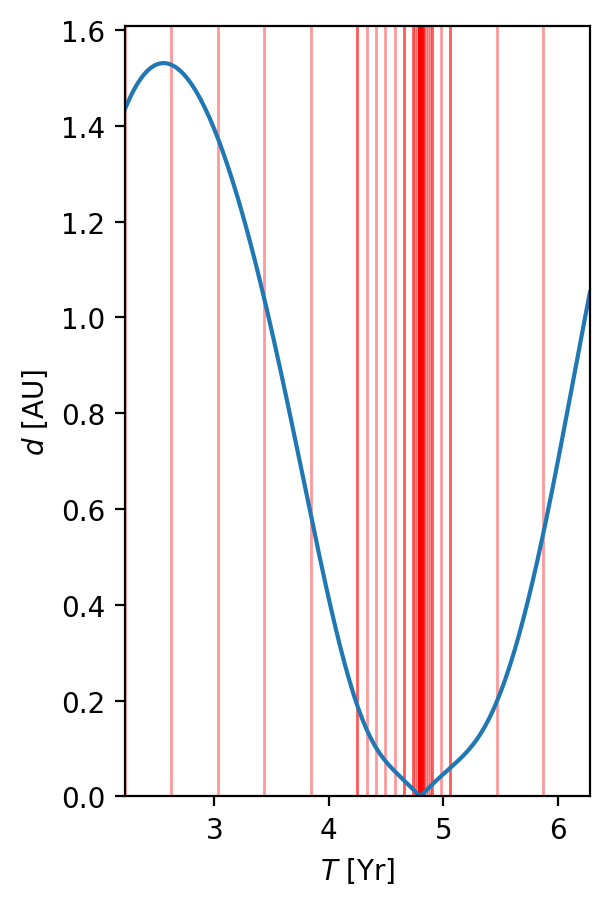

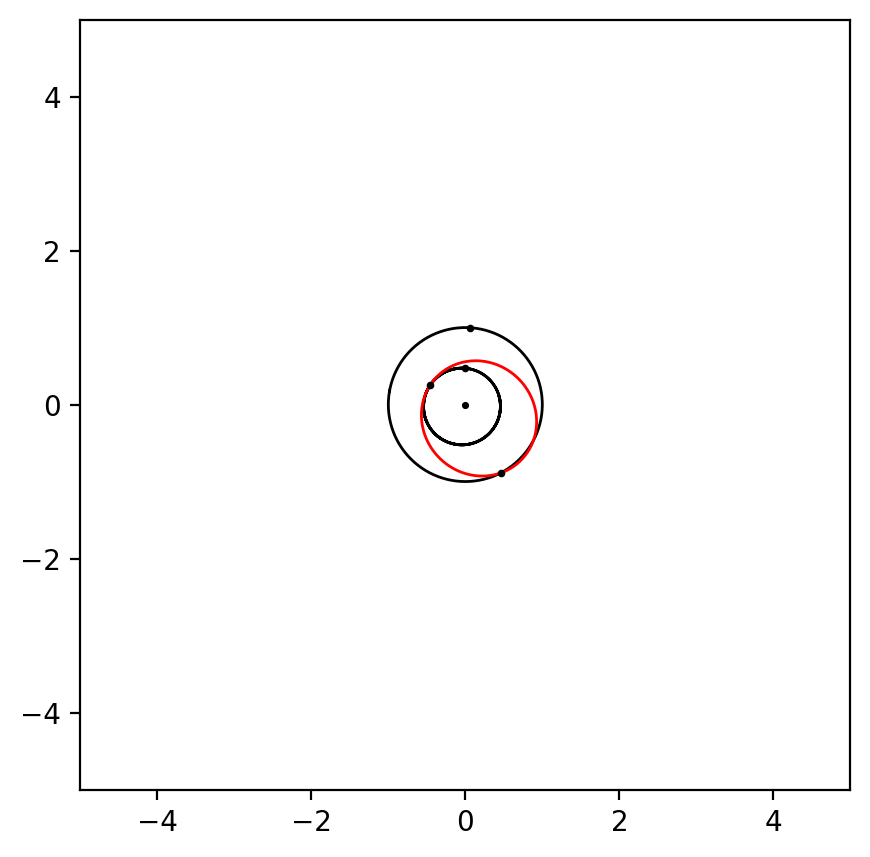

In [14]:

def minima_finder(t0, tf, distance_func, n=5, max_iter=100, tol=1e-12):
    num_points = 2*n + 1

    # --- build initial grid manually ---
    tlist = [0.0] * num_points
    for i in range(num_points):
        tlist[i] = t0 + (i / (num_points - 1)) * (tf - t0)

    def find_minidx(tlist):
        min_idx = 0
        min_val = distance_func(tlist[0])
        for i in range(1, len(tlist)):
            val = distance_func(tlist[i])
            if val < min_val:
                min_val = val
                min_idx = i

        return min_idx

    min_t = float('inf')
    max_i = max_iter

    for i in range(max_iter):

        # plot
        for j in range(num_points):
            plt.axvline(tlist[j], color='r', lw=1, alpha=0.4)

        minidx = find_minidx(tlist)

        # --- proper bracketing ---
        if minidx == 0:
            p0 = tlist[0]
            pm = tlist[1]
            pf = tlist[2]
        elif minidx == num_points - 1:
            p0 = tlist[-3]
            pm = tlist[-2]
            pf = tlist[-1]
        else:
            p0 = tlist[minidx - 1]
            pm = tlist[minidx]
            pf = tlist[minidx + 1]

        if i == max_iter - 1:
            min_t = pm

        # convergence check
        if (abs(p0 - pm) < tol) and (abs(pm - pf) < tol):
            min_t = pm
            max_i = i
            break

        # --- build new centered stencil manually ---
        spacing = (pf - p0) / (2*n)

        new_tlist = [0.0] * num_points
        idx = 0
        for k in range(-n, n+1):
            new_tlist[idx] = pm + k * spacing
            idx += 1

        tlist = new_tlist

    print(max_i)

    # --- edge warning ---
    f_left = distance_func(t0)
    f_right = distance_func(tf)
    f_min = distance_func(min_t)

    if f_left <= f_min or f_right <= f_min:
        print(f"[ CAUTION ] Global minima may be at or outside [{t0}, {tf}]")

    return min_t

plt.figure(figsize=(3,5),dpi=200)
t_min = minima_finder(t.min(),t.max(),distance_func)
print(t_min, distance_func(t_min))
plt.plot(t,[distance_func(t_x) for t_x in t]) 
plt.xlim(t.min(),t.max())
plt.ylim(0,None)
plt.xlabel("$T$ [Yr]")
plt.ylabel("$d$ [AU]")
plt.show()

idxc = np.argmin(np.abs(t-t_min))
plt.figure(figsize = (5,5),dpi = 200)
plt.plot(ro1[0],ro1[1],'k-',lw=1)
plt.plot(ro2[0],ro2[1],'k-',lw=1)
plt.plot(rt1[0],rt1[1],'r-',lw=1)
plt.scatter(0,0,color='k',s=2.5)
plt.scatter(ro1[0][idx0],ro1[1][idx0],color='k',s=3,zorder =5)
plt.scatter(ro2[0][idx0],ro2[1][idx0],color='k',s=3,zorder =5)
plt.scatter(ro1[0][idx1],ro1[1][idx1],color='k',s=3,zorder =5)
plt.scatter(ro2[0][idx1],ro2[1][idx1],color='k',s=3,zorder =5)
# plt.scatter(ro1[0][idxc],ro1[1][idxc],color='k',s=3,zorder =5)
# plt.scatter(ro2[0][idxc],ro2[1][idxc],color='k',s=3,zorder =5)
plt.xlim(-sq,sq)
plt.ylim(-sq,sq)
plt.gca().set_aspect("equal")
plt.show() 

4.803373523100184 0.0008950748392602258


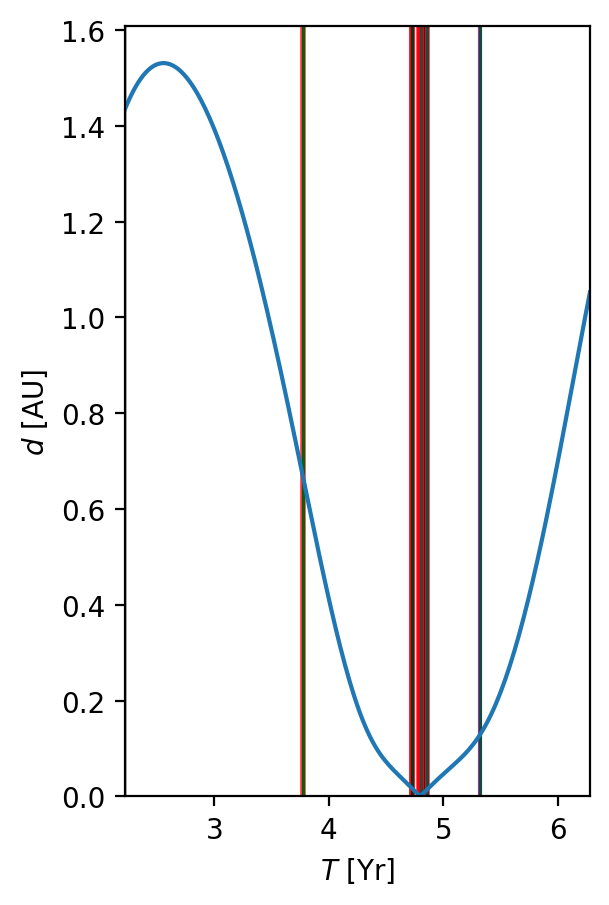

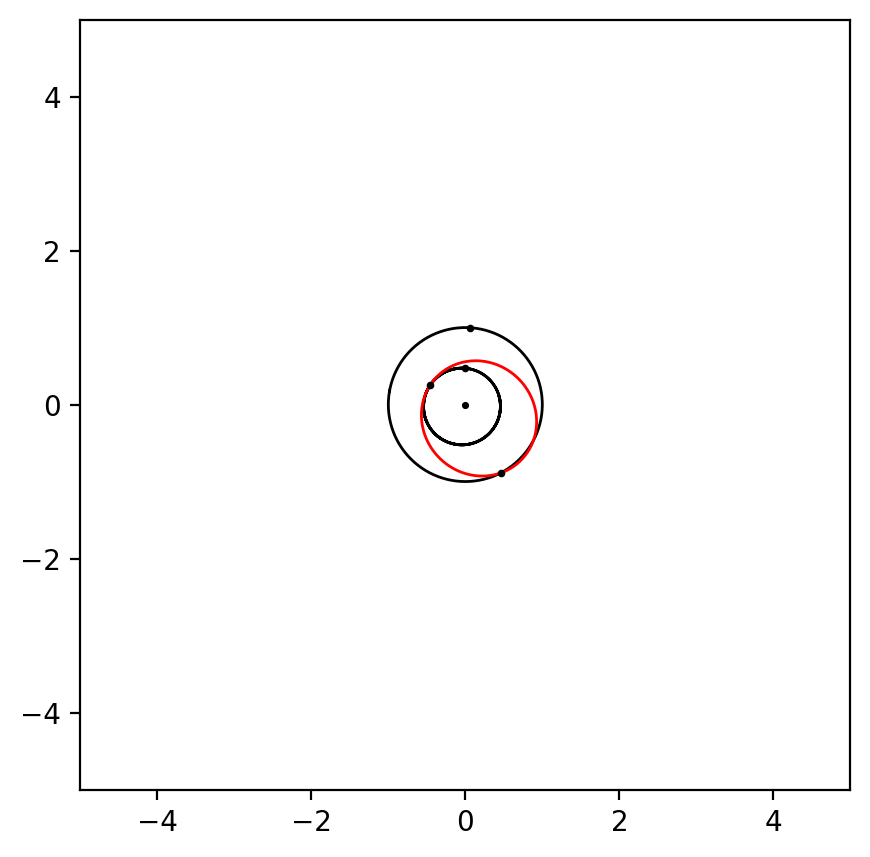

In [15]:
def brent_minimize(a, b, f, tol=1e-12, max_iter=100):
    import matplotlib.pyplot as plt

    K = 0.3819660112501051  # (3 - sqrt(5)) / 2

    x = a + K * (b - a)
    w = x
    v = x

    fx = f(x)
    fw = fx
    fv = fx

    d = 0.0
    e = 0.0

    for i in range(max_iter):

        # --- VISUALIZE CURRENT STATE ---
        plt.axvline(a, color='black', lw=1, alpha=0.3)   # left bound
        plt.axvline(b, color='black', lw=1, alpha=0.3)   # right bound

        plt.axvline(x, color='red', lw=2, alpha=0.8)     # current best
        plt.axvline(w, color='blue', lw=1, alpha=0.6)    # previous best
        plt.axvline(v, color='green', lw=1, alpha=0.6)   # older point

        m = 0.5 * (a + b)
        tol1 = tol * abs(x) + 1e-15
        tol2 = 2.0 * tol1

        if abs(x - m) <= (tol2 - 0.5 * (b - a)):
            break

        use_parabolic = False

        # --- PARABOLIC STEP ---
        if abs(e) > tol1:
            r = (x - w) * (fx - fv)
            q = (x - v) * (fx - fw)
            p = (x - v) * q - (x - w) * r
            q = 2.0 * (q - r)

            if q > 0.0:
                p = -p
            else:
                q = -q

            if (abs(p) < abs(0.5 * q * e)) and (p > q * (a - x)) and (p < q * (b - x)):
                d = p / q
                u = x + d
                use_parabolic = True

                if (u - a) < tol2 or (b - u) < tol2:
                    if x < m:
                        d = tol1
                    else:
                        d = -tol1

        # --- GOLDEN STEP ---
        if not use_parabolic:
            if x < m:
                e = b - x
            else:
                e = a - x
            d = K * e

        # --- NEW PROBE ---
        if abs(d) >= tol1:
            u = x + d
        else:
            if d > 0:
                u = x + tol1
            else:
                u = x - tol1

        # --- VISUALIZE PROBE ---
        plt.axvline(u, color='purple', lw=1.5, alpha=0.8)  # new sample

        fu = f(u)

        # --- UPDATE ---
        if fu <= fx:
            if u < x:
                b = x
            else:
                a = x

            v = w
            fv = fw
            w = x
            fw = fx
            x = u
            fx = fu
        else:
            if u < x:
                a = u
            else:
                b = u

            if (fu <= fw) or (w == x):
                v = w
                fv = fw
                w = u
                fw = fu
            elif (fu <= fv) or (v == x) or (v == w):
                v = u
                fv = fu

        e = d

    return x

plt.figure(figsize=(3,5),dpi=200)
t_min = brent_minimize(t.min(),t.max(),distance_func)
print(t_min, distance_func(t_min))
plt.plot(t,[distance_func(t_x) for t_x in t]) 
plt.xlim(t.min(),t.max())
plt.ylim(0,None)
plt.xlabel("$T$ [Yr]")
plt.ylabel("$d$ [AU]")
plt.show()

idxc = np.argmin(np.abs(t-t_min))
plt.figure(figsize = (5,5),dpi = 200)
plt.plot(ro1[0],ro1[1],'k-',lw=1)
plt.plot(ro2[0],ro2[1],'k-',lw=1)
plt.plot(rt1[0],rt1[1],'r-',lw=1)
plt.scatter(0,0,color='k',s=2.5)
plt.scatter(ro1[0][idx0],ro1[1][idx0],color='k',s=3,zorder =5)
plt.scatter(ro2[0][idx0],ro2[1][idx0],color='k',s=3,zorder =5)
plt.scatter(ro1[0][idx1],ro1[1][idx1],color='k',s=3,zorder =5)
plt.scatter(ro2[0][idx1],ro2[1][idx1],color='k',s=3,zorder =5)
# plt.scatter(ro1[0][idxc],ro1[1][idxc],color='k',s=3,zorder =5)
# plt.scatter(ro2[0][idxc],ro2[1][idxc],color='k',s=3,zorder =5)
plt.xlim(-sq,sq)
plt.ylim(-sq,sq)
plt.gca().set_aspect("equal")
plt.show() 

4.792794370780689 0.0008950748392602258


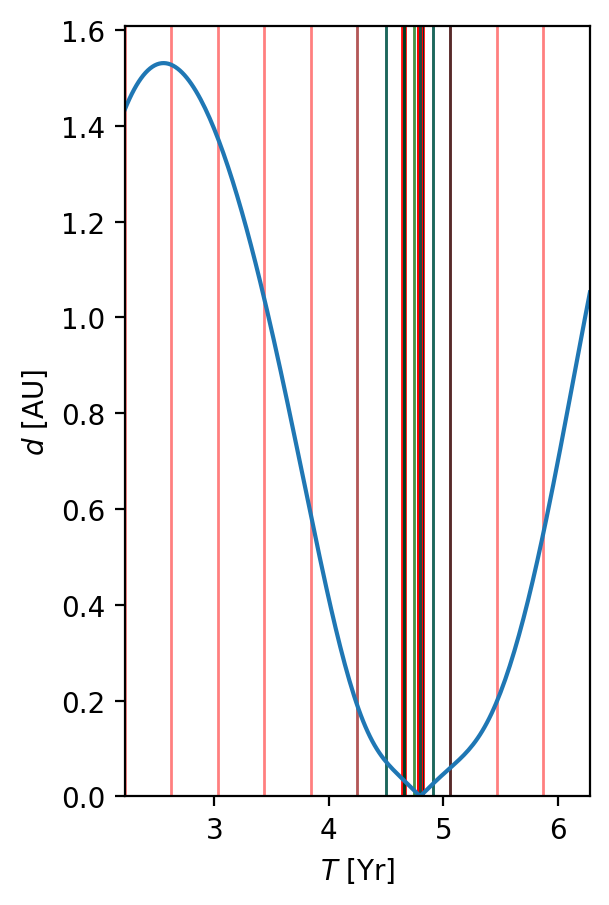

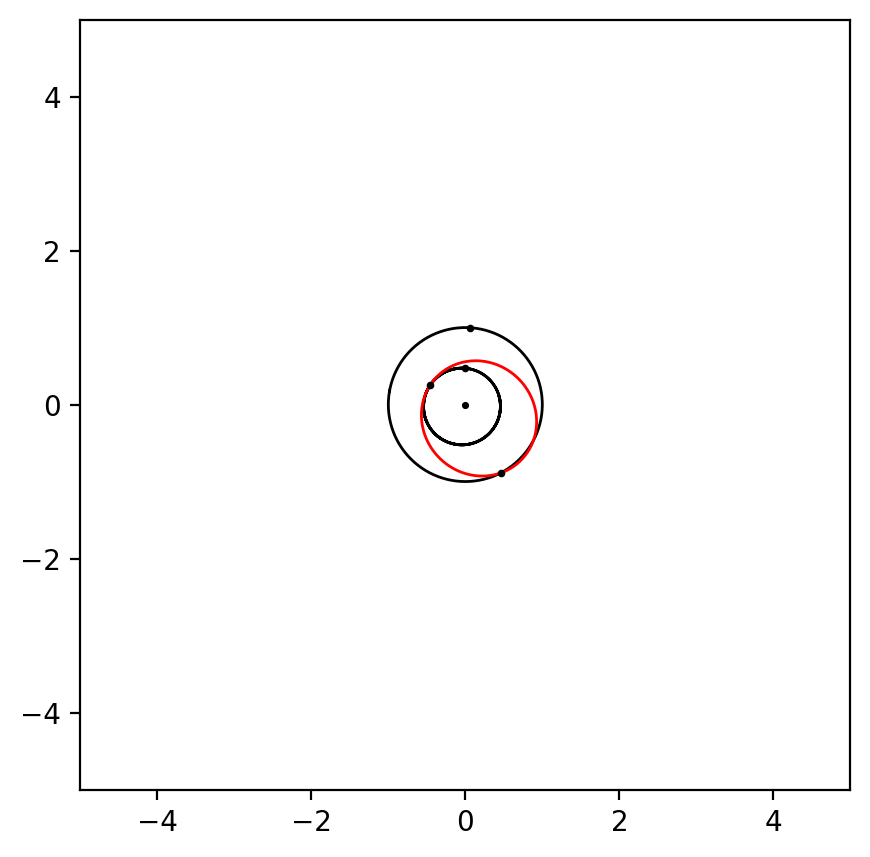

In [16]:
def global_minima_finder(
        t0,
        tf,
        f,
        n=11,
        max_iter=100,
        tol=1e-12
    ):
    ## t0 - left boundary, tf right boundary
    ## f is evaluation function, distance in this case
    ## n is number of coarse scan divisions
    ## max_iter is maximum iterations of local search
    ## tol is tolerance

    # -----------------------------
    # coarse grid
    # -----------------------------
    t_list = [0.0] * n
    for i in range(n):
        t_list[i] = t0 + (i / (n - 1)) * (tf - t0)
        plt.axvline(t_list[i],color='r',lw=1,alpha = 0.5)

    # -----------------------------
    # detect candidate minima
    # -----------------------------
    # find f(t[i]) where left and right neigbors are greater than it
    # include endpoints in the candidate idx because this method doesnt catch em
    minima_idx = [0,n-1]
    for i in range(1, n - 1):
        if f(t_list[i]) < f(t_list[i - 1]) and f(t_list[i]) < f(t_list[i + 1]):
            minima_idx.append(i)

    # -----------------------------
    # Brent minimizer (core)
    # -----------------------------
    def brent_min(a, b):

        CGOLD = 0.3819660112501051
        ZEPS = 1e-18

        x = w = v = a + 0.5 * (b - a)
        fx = fw = fv = f(x)

        d = 0.0
        e = 0.0

        for _ in range(max_iter):

              # --- VISUALIZE CURRENT STATE ---
            plt.axvline(a, color='black', lw=1, alpha=0.3)   # left bound
            plt.axvline(b, color='black', lw=1, alpha=0.3)   # right bound

            plt.axvline(x, color='red', lw=2, alpha=0.8)     # current best
            plt.axvline(w, color='blue', lw=1, alpha=0.6)    # previous best
            plt.axvline(v, color='green', lw=1, alpha=0.6)   # older point
            
            xm = 0.5 * (a + b)
            tol1 = tol * abs(x) + ZEPS
            tol2 = 2.0 * tol1

            # convergence check
            if abs(x - xm) <= (tol2 - 0.5 * (b - a)):
                return x

            # attempt parabolic fit
            p = q = r = 0.0

            if abs(e) > tol1:

                r = (x - w) * (fx - fv)
                q = (x - v) * (fx - fw)
                p = (x - v) * q - (x - w) * r
                q = 2.0 * (q - r)

                if q > 0:
                    p = -p
                q = abs(q)

                etemp = e
                e = d

                if (abs(p) < abs(0.5 * q * etemp)) and (p > q * (a - x)) and (p < q * (b - x)):
                    d = p / q
                    u = x + d

                    if (u - a < tol2) or (b - u < tol2):
                        d = tol1 if x < xm else -tol1

                else:
                    e = (b - x) if x < xm else (a - x)
                    d = CGOLD * e

            else:
                e = (b - x) if x < xm else (a - x)
                d = CGOLD * e

            # next point
            u = x + (d if abs(d) >= tol1 else (tol1 if d > 0 else -tol1))
            fu = f(u)

            # update brackets
            if fu <= fx:

                if u >= x:
                    a = x
                else:
                    b = x

                v, w, x = w, x, u
                fv, fw, fx = fw, fx, fu

            else:
                if u < x:
                    a = u
                else:
                    b = u

                if fu <= fw or w == x:
                    v, w = w, u
                    fv, fw = fw, fu
                elif fu <= fv or v == x or v == w:
                    v = u
                    fv = fu

        return x

    # -----------------------------
    # refine candidates
    # -----------------------------
    # check which are the lowest minima
    best_t = None
    best_f = float('inf')

    for midx in minima_idx:
        if midx == 0:
            t_candidate = t_list[0]
            f_candidate = f(t_candidate)

        elif midx == n - 1:
            t_candidate = t_list[n - 1]
            f_candidate = f(t_candidate)

        else:
            a = t_list[midx - 1]
            b = t_list[midx + 1]
            t_candidate = brent_min(a, b)
            f_candidate = f(t_candidate)

        if f_candidate < best_f:
            best_f = f_candidate
            best_t = t_candidate

    # -----------------------------
    # fallback if no local minima found
    # -----------------------------
    if best_t is None:
        best_t = t_list[0]
        best_f = f(best_t)

        for t in t_list:
            ft = f(t)
            if ft < best_f:
                best_f = ft
                best_t = t

    # -----------------------------
    # boundary warning if the lowest minima is at the endpoints
    # -----------------------------
    if abs(best_t - t0) < 5 * tol or abs(best_t - tf) < 5 * tol:
        print(f"[ CAUTION ]: minima might lie outside [{t0}, {tf}]")

    return best_t

plt.figure(figsize=(3,5),dpi=200)
t_min = global_minima_finder(t.min(),t.max(),distance_func)
print(t_min, distance_func(t_min))
plt.plot(t,[distance_func(t_x) for t_x in t]) 
plt.xlim(t.min(),t.max())
plt.ylim(0,None)
plt.xlabel("$T$ [Yr]")
plt.ylabel("$d$ [AU]")
plt.show()

idxc = np.argmin(np.abs(t-t_min))
plt.figure(figsize = (5,5),dpi = 200)
plt.plot(ro1[0],ro1[1],'k-',lw=1)
plt.plot(ro2[0],ro2[1],'k-',lw=1)
plt.plot(rt1[0],rt1[1],'r-',lw=1)
plt.scatter(0,0,color='k',s=2.5)
plt.scatter(ro1[0][idx0],ro1[1][idx0],color='k',s=3,zorder =5)
plt.scatter(ro2[0][idx0],ro2[1][idx0],color='k',s=3,zorder =5)
plt.scatter(ro1[0][idx1],ro1[1][idx1],color='k',s=3,zorder =5)
plt.scatter(ro2[0][idx1],ro2[1][idx1],color='k',s=3,zorder =5)
# plt.scatter(ro1[0][idxc],ro1[1][idxc],color='k',s=3,zorder =5)
# plt.scatter(ro2[0][idxc],ro2[1][idxc],color='k',s=3,zorder =5)
plt.xlim(-sq,sq)
plt.ylim(-sq,sq)
plt.gca().set_aspect("equal")
plt.show() 

In [17]:
# kos very big number 
3.402823E+38

3.402823e+38

C:\Users\verci\AppData\Local\Temp\ipykernel_18036\3923243617.py:260: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  cross_r1r2 = np.cross(r1, r2)


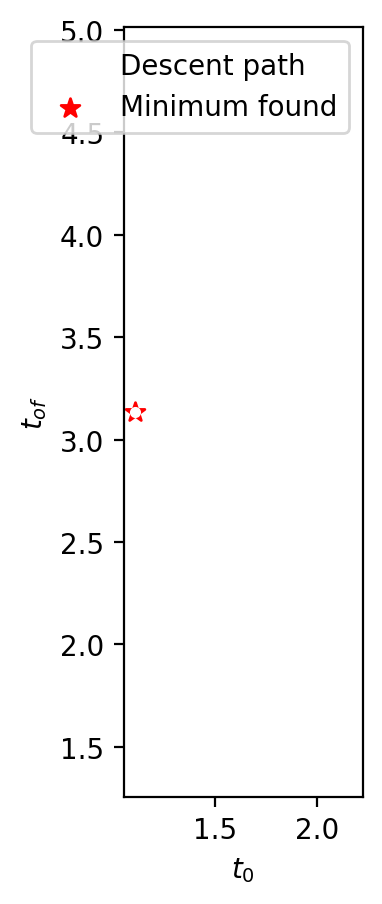


Optimal solution found:
t0 = 1.111
tof = 3.137
deltaV = 0.3663


In [18]:
def gradient_descent_search(deltaV_func, t_range, tof_range, initial_point, step_size=2, max_iterations=100):
    """
    Gradient-free descent using neighbor checking.
    
    Parameters:
    - deltaV_func: function that takes (t, tof) and returns deltaV
    - t_range: (min_t, max_t) tuple
    - tof_range: (min_tof, max_tof) tuple
    - initial_point: (t0, tof0) starting point
    - step_size: how many steps to jump when moving to a neighbor (default 2)
    - max_iterations: max number of iterations
    """
    
    current_t, current_tof = initial_point
    current_dv = deltaV_func(current_t, current_tof)
    
    # Store the path for visualization
    path = [(current_t, current_tof, current_dv)]
    
    for iteration in range(max_iterations):
        # Check all 4 neighbors: i+step, i-step, j+step, j-step
        neighbors = [
            (current_t + step_size, current_tof),  # right
            (current_t - step_size, current_tof),  # left
            (current_t, current_tof + step_size),  # up
            (current_t, current_tof - step_size)   # down
        ]
        
        # Filter neighbors within bounds
        valid_neighbors = []
        for t_n, tof_n in neighbors:
            if (t_range[0] <= t_n <= t_range[1] and 
                tof_range[0] <= tof_n <= tof_range[1]):
                valid_neighbors.append((t_n, tof_n))
        
        # Evaluate all neighbors
        neighbor_values = []
        for t_n, tof_n in valid_neighbors:
            dv = deltaV_func(t_n, tof_n)
            neighbor_values.append((t_n, tof_n, dv))
        
        # Find the best neighbor (lowest deltaV)
        if neighbor_values:
            best_t, best_tof, best_dv = min(neighbor_values, key=lambda x: x[2])
        else:
            break  # No valid neighbors
        
        # If all neighbors are worse (higher deltaV), we found a minimum
        if best_dv >= current_dv:
            print(f"Found minimum at iteration {iteration}")
            print(f"t0 = {current_t}, tof = {current_tof}, deltaV = {current_dv}")
            break
        
        # Otherwise, jump to the best neighbor
        current_t, current_tof, current_dv = best_t, best_tof, best_dv
        path.append((current_t, current_tof, current_dv))
        
        print(f"Iteration {iteration}: moved to t={current_t:.3f}, tof={current_tof:.3f}, dv={current_dv:.4f}")
    
    return current_t, current_tof, current_dv, path

# How to integrate this with your existing code:

# First, create a function that computes deltaV for any (t, tof)
def compute_deltaV(t0, tof_val):
    """Compute deltaV for a given departure time and time-of-flight"""
    t_arrival = t0 + tof_val
    
    # Check bounds
    if t0 > Tref or t_arrival > t[-1]:
        return np.inf
    
    # Find indices
    idx0 = np.argmin(np.abs(t - t0))
    idx1 = np.argmin(np.abs(t - t_arrival))
    
    # Solve Lambert
    vt1, vt2 = lambert_solver(ro1.T[idx0], ro2.T[idx1], tof_val, mu, +1)
    if np.dot(vo1.T[idx0], vt1) < 0:
        vt1, vt2 = lambert_solver(ro1.T[idx0], ro2.T[idx1], tof_val, mu, -1)
    
    # Return deltaV (choose 1-way or 2-way)
    return np.linalg.norm(vt1 - vo1.T[idx0])  # 1-way
    # or for 2-way:
    # return np.linalg.norm(vt1 - vo1.T[idx0]) + np.linalg.norm(vt2 - vo2.T[idx1])

# Define search bounds
t_min, t_max = 0, Tref
tof_min, tof_max = tof.min(), tof.max()

# Choose starting point (e.g., from your brute force solution or random)
initial_t = Tref / 2
initial_tof = (tof_min + tof_max) / 2

# Run gradient-free descent
optimal_t, optimal_tof, optimal_dv, search_path = gradient_descent_search(
    deltaV_func=compute_deltaV,
    t_range=(t_min, t_max),
    tof_range=(tof_min, tof_max),
    initial_point=(initial_t, initial_tof),
    step_size=2,  # Jump by 2 indices initially
    max_iterations=50
)

# Visualize the search path on your porkchop plot
plt.figure(figsize=(5,5),dpi=200)
plt.imshow(deltaV_array.T, extent=[t.min(), Tref, tof.min(), tof.max()], 
           cmap="inferno", origin='lower')
plt.xlabel("$t_0$")
plt.ylabel("$t_{of}$")

# Plot the search path
path_t = [p[0] for p in search_path]
path_tof = [p[1] for p in search_path]
plt.plot(path_t, path_tof, 'wo-', markersize=3, linewidth=1, label='Descent path')
plt.scatter(optimal_t, optimal_tof, color='red', s=50, marker='*', label='Minimum found')
plt.legend()
plt.show()

print(f"\nOptimal solution found:")
print(f"t0 = {optimal_t:.3f}")
print(f"tof = {optimal_tof:.3f}")
print(f"deltaV = {optimal_dv:.4f}")

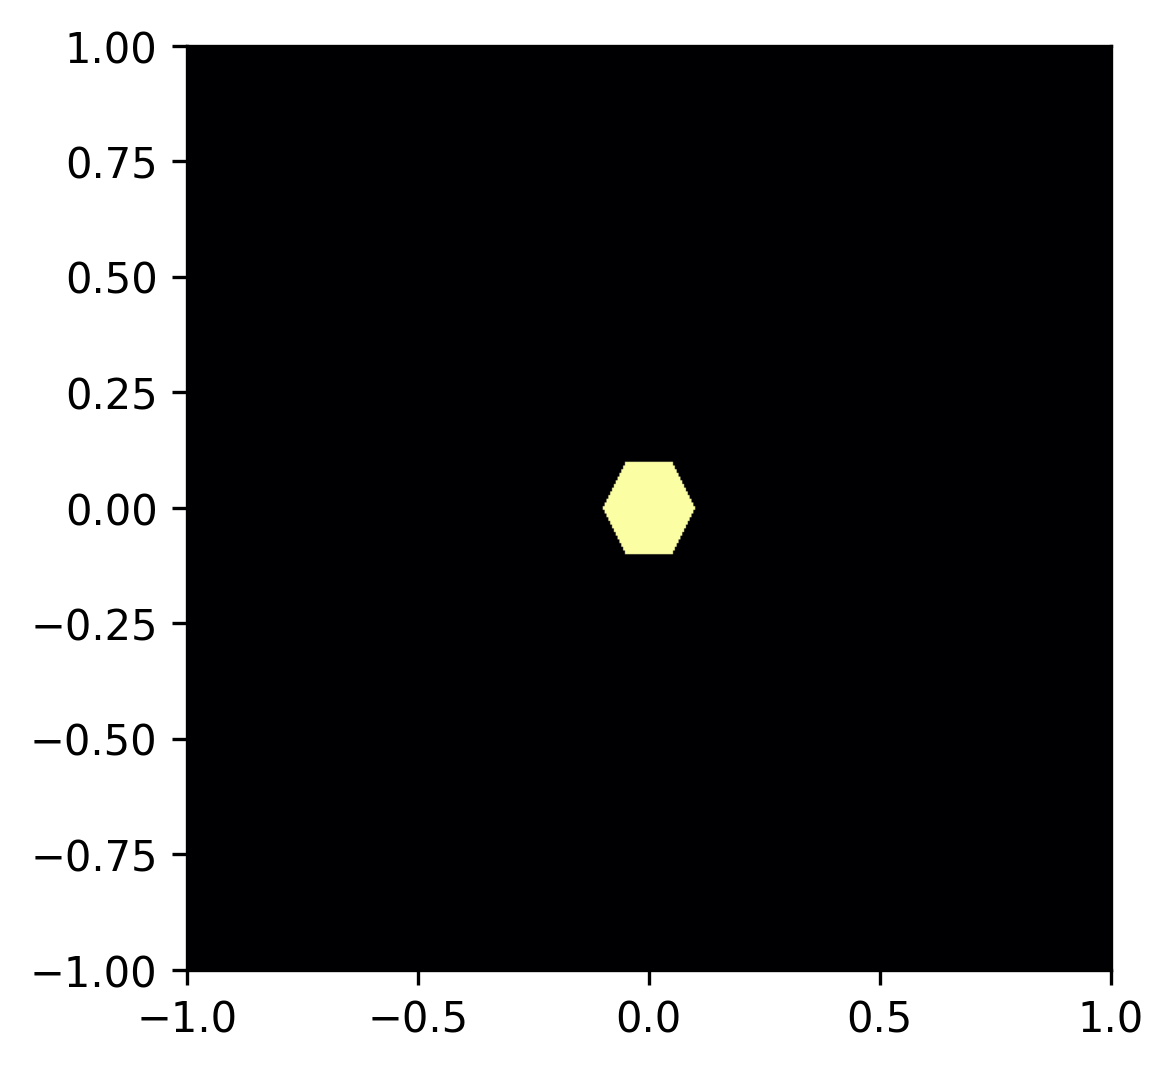

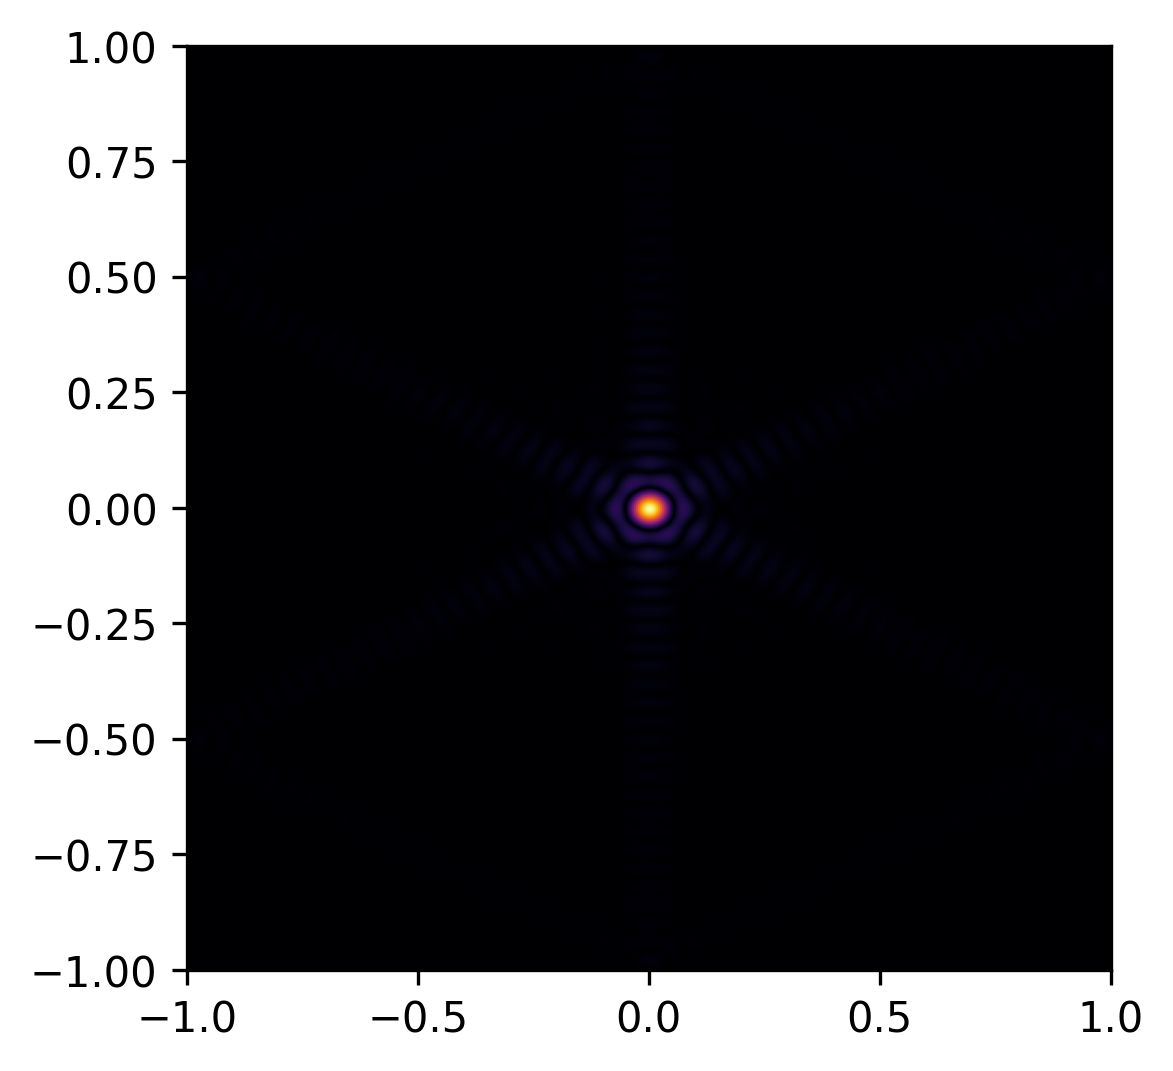

In [38]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-1,1,500)
y = np.linspace(-1,1,500)
xv,yv = np.meshgrid(x,y)

T = (np.maximum(np.abs(xv), np.abs(yv)) <= 0.1) & (np.abs(xv) + 0.5*np.abs(yv) <= 0.1)

# FFT
F = np.fft.fft2(T)
F_shifted = np.fft.fftshift(F)
F_mag = np.abs(F_shifted)

plt.figure(figsize=(4,4),dpi = 300)
plt.imshow(T,extent=[-1,1,-1,1],cmap='inferno')
plt.show()

plt.figure(figsize=(4,4),dpi = 300)
plt.imshow((F_mag),extent=[-1,1,-1,1],cmap='inferno')
plt.show()